<a href="https://colab.research.google.com/github/karthikoo7/Machine_Learning-BDA-/blob/main/Basic_Classification_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/cleaned_76hd.csv')
df.shape

(282, 39)

In [3]:
df['V58'].unique()

array([0, 1])

In [4]:
X = df.drop(columns=['V58'])
Y = df['V58']
X.shape,Y.shape

((282, 38), (282,))

In [5]:
from sklearn.model_selection import train_test_split

In [17]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=7,stratify=Y)

X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((197, 38), (85, 38), (197,), (85,))

what does stratify=y do? Answer below

In [18]:
Y.value_counts(normalize=True)

,proportion
V58,
0,0.546099
1,0.453901


In [19]:
Y_train.value_counts(normalize=True) ## we get same distribution in both the original and training data

,proportion
V58,
0,0.548223
1,0.451777


In [20]:
Y_test.value_counts(normalize=True) # ratio of distribution of data remains same as in roginal data

,proportion
V58,
0,0.541176
1,0.458824


Important to standardize data for SVM, Optional for Logistic but preferred.

In [21]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [23]:
X_train_sc.mean(),X_test_sc.mean() # close to 0

(np.float64(-4.0220743291256e-17), np.float64(0.00744590513160098))

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

Apply ML Models

In [29]:
lr = LogisticRegression(class_weight='balanced',random_state=7)
lr.fit(X_train_sc,Y_train)
Y_pred = lr.predict(X_test_sc)

In [30]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81        46
           1       0.78      0.79      0.78        39

    accuracy                           0.80        85
   macro avg       0.80      0.80      0.80        85
weighted avg       0.80      0.80      0.80        85



Naive B


In [34]:
gnb = GaussianNB()
gnb.fit(X_train_sc,Y_train)
Y_pred = gnb.predict(X_test_sc)
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.63      1.00      0.77        46
           1       1.00      0.31      0.47        39

    accuracy                           0.68        85
   macro avg       0.82      0.65      0.62        85
weighted avg       0.80      0.68      0.63        85



In [35]:
bnb = BernoulliNB()
bnb.fit(X_train_sc,Y_train)
Y_pred = bnb.predict(X_test_sc)

print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83        46
           1       0.83      0.74      0.78        39

    accuracy                           0.81        85
   macro avg       0.81      0.81      0.81        85
weighted avg       0.81      0.81      0.81        85



SVM

In [36]:
svm = SVC(class_weight='balanced')
svm.fit(X_train_sc,Y_train)
Y_pred = svm.predict(X_test_sc)

print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.78      0.85      0.81        46
           1       0.80      0.72      0.76        39

    accuracy                           0.79        85
   macro avg       0.79      0.78      0.78        85
weighted avg       0.79      0.79      0.79        85



KNN Classifier

In [37]:
knnc = KNeighborsClassifier()
knnc.fit(X_train_sc,Y_train)
Y_pred = knnc.predict(X_test_sc)

print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.78      0.87      0.82        46
           1       0.82      0.72      0.77        39

    accuracy                           0.80        85
   macro avg       0.80      0.79      0.80        85
weighted avg       0.80      0.80      0.80        85



Decision Tree Classifier


In [40]:
dt = DecisionTreeClassifier(criterion='gini',class_weight='balanced')
dt.fit(X_train_sc,Y_train)
Y_pred = dt.predict(X_test_sc)

print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       0.74      0.63      0.68        46
           1       0.63      0.74      0.68        39

    accuracy                           0.68        85
   macro avg       0.69      0.69      0.68        85
weighted avg       0.69      0.68      0.68        85



See the Decision Tree

In [41]:
from sklearn.tree import export_text


In [44]:
print(export_text(dt,max_depth=2))

|--- feature_34 <= 0.96
|   |--- feature_33 <= -0.16
|   |   |--- feature_23 <= -2.33
|   |   |   |--- class: 1
|   |   |--- feature_23 >  -2.33
|   |   |   |--- truncated branch of depth 7
|   |--- feature_33 >  -0.16
|   |   |--- feature_1 <= -0.40
|   |   |   |--- truncated branch of depth 3
|   |   |--- feature_1 >  -0.40
|   |   |   |--- truncated branch of depth 4
|--- feature_34 >  0.96
|   |--- feature_2 <= -0.03
|   |   |--- feature_33 <= -0.16
|   |   |   |--- truncated branch of depth 5
|   |   |--- feature_33 >  -0.16
|   |   |   |--- truncated branch of depth 2
|   |--- feature_2 >  -0.03
|   |   |--- feature_27 <= -1.62
|   |   |   |--- class: 0
|   |   |--- feature_27 >  -1.62
|   |   |   |--- truncated branch of depth 4



Evalution Metrics

In [50]:
from sklearn.naive_bayes import MultinomialNB
model_list = [DecisionTreeClassifier(random_state=7),
              LogisticRegression(random_state=7),
              GaussianNB(),
              BernoulliNB(),
              MultinomialNB(),
              SVC(random_state=7)]

In [51]:
def eval_model(model,X_train,X_test,y_train,y_test):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    p,r,f,s = precision_recall_fscore_support(y_test,y_pred)
    acc = accuracy_score(y_test,y_pred)
    # print(model.__class__)
    # print(prfs)
    # print(acc)
    return p,r,f,s,acc

In [55]:
from sklearn.metrics import precision_recall_fscore_support,accuracy_score
pc1 = []
pc2=[]
rc1=[]
rc2=[]
fc1=[]
fc2=[]
acc_list=[]
for model in model_list:
    p,r,f,s,acc = eval_model(model,X_train,X_test,Y_train,Y_test)
    pc1.append(p[0])
    pc2.append(p[1])
    rc1.append(r[0])
    rc2.append(r[1])
    fc1.append(f[0])
    fc2.append(f[1])
    acc_list.append(acc)

In [56]:
result_dict = {
    "pc1" : pc1,
    "pc2" : pc2,
    "rc1" : rc1,
    "rc2" : rc2,
    "fc1" : fc1,
    "fc2" : fc2,
    "acc" : acc_list
}

In [57]:
# Create DF using all lists

result_df = pd.DataFrame(result_dict)
result_df

,pc1,pc2,rc1,rc2,fc1,fc2,acc
0,0.761905,0.674419,0.695652,0.743590,0.727273,0.707317,0.717647
1,0.822222,0.775000,0.804348,0.794872,0.813187,0.784810,0.800000
2,0.647887,1.000000,1.000000,0.358974,0.786325,0.528302,0.705882
3,0.829787,0.815789,0.847826,0.794872,0.838710,0.805195,0.823529
4,0.822222,0.775000,0.804348,0.794872,0.813187,0.784810,0.800000
5,0.808511,0.789474,0.826087,0.769231,0.817204,0.779221,0.800000


<Axes: >

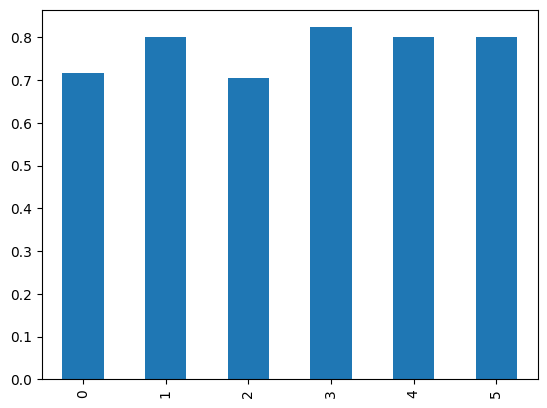

In [58]:
result_df["acc"].plot.bar()

Simulation

In [60]:
def sim(model,X,y):
    X_train,X_test,y_train,y_test = train_test_split(X,Y,
                                                 test_size=0.3,
                                                 stratify=y)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    return acc

In [66]:
sim_result = []
for i in range(10):
    model = SVC(random_state=7)
    acc = sim(model,X,Y)
    sim_result.append(acc)

In [67]:
sim_result

[0.8823529411764706,
 0.8235294117647058,
 0.7764705882352941,
 0.788235294117647,
 0.8588235294117647,
 0.8235294117647058,
 0.7764705882352941,
 0.8352941176470589,
 0.8,
 0.7764705882352941]

In [68]:
sum(sim_result) / len(sim_result)

0.8141176470588235